# PCA on Iris Dataset (sklearn)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['Species'] = iris.target_names[iris.target]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris_df.shape

(150, 5)

In [ ]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
iris_df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

## Step 1: Standardize the Features

In [ ]:
X = iris_df.drop('Species', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## Step 2: PCA with All 4 Components (Explained Variance)

In [ ]:
pca = PCA(n_components=4)
pca.fit(X_scaled)
print('Explained variance ratio:', pca.explained_variance_ratio_)

Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]


In [ ]:
dataframe = pd.DataFrame({
    'variance': pca.explained_variance_ratio_,
    'Principal Component': ['PC1', 'PC2', 'PC3', 'PC4']
})
dataframe

,variance,Principal Component
0,0.729624,PC1
1,0.228508,PC2
2,0.036689,PC3
3,0.005179,PC4


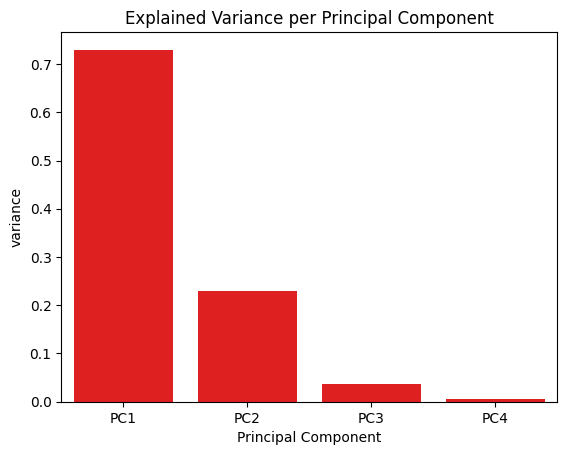

In [ ]:
sns.barplot(x='Principal Component', y='variance', data=dataframe, color='Red')
plt.title('Explained Variance per Principal Component')
plt.show()

## Step 3: Reduce to 2 Principal Components

In [ ]:
pca_2 = PCA(n_components=2)
pca_2d = pca_2.fit_transform(X_scaled)
print('Shape after PCA:', pca_2d.shape)
print('Explained variance (2 PCs):', pca_2.explained_variance_ratio_)
print('Total variance retained:', pca_2.explained_variance_ratio_.sum())

Shape after PCA: (150, 2)
Explained variance (2 PCs): [0.72962445 0.22850762]
Total variance retained: 0.9581320720000163


In [ ]:
pca_df = pd.DataFrame(pca_2d, columns=['PC1', 'PC2'])
pca_df['Species'] = iris_df['Species']
pca_df.head()

,PC1,PC2,Species
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


## Step 4: 2D Scatter Plot of PCA

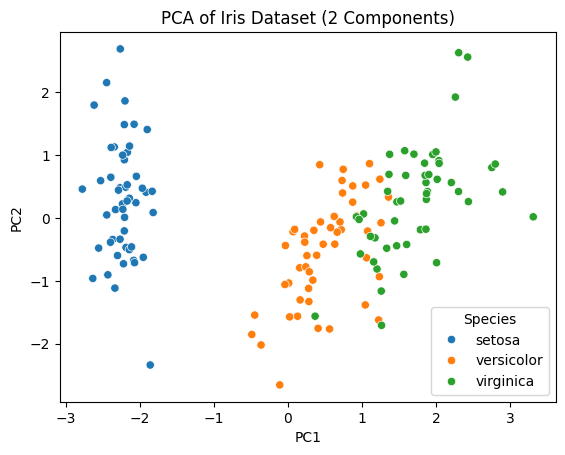

In [ ]:
sns.scatterplot(x='PC1', y='PC2', hue='Species', data=pca_df)
plt.title('PCA of Iris Dataset (2 Components)')
plt.show()

## Step 5: Verify Orthogonality of Components

In [ ]:
np.dot(pca_2.components_[0], pca_2.components_[1])

np.float64(-2.7755575615628914e-17)

## Step 6: Covariance Matrix (on Scaled Data)

In [ ]:
covariance_matrix = np.cov(X_scaled.T)
covariance_matrix

array([[ 1.00671141, -0.11835884,  0.87760447,  0.82343066],
       [-0.11835884,  1.00671141, -0.43131554, -0.36858315],
       [ 0.87760447, -0.43131554,  1.00671141,  0.96932762],
       [ 0.82343066, -0.36858315,  0.96932762,  1.00671141]])

## Step 7: Eigenvalues and Eigenvectors

In [ ]:
eigen_values, eigen_vectors = np.linalg.eigh(covariance_matrix)

In [ ]:
eigen_values

array([0.02085386, 0.14774182, 0.9201649 , 2.93808505])

In [ ]:
eigen_vectors

array([[ 0.26128628,  0.71956635,  0.37741762, -0.52106591],
       [-0.12350962, -0.24438178,  0.92329566,  0.26934744],
       [-0.80144925, -0.14212637,  0.02449161, -0.5804131 ],
       [ 0.52359713, -0.63427274,  0.06694199, -0.56485654]])

In [ ]:
eigen_pairs = [(np.abs(eigen_values[i]), eigen_vectors[:, i]) for i in range(len(eigen_values))]
eigen_pairs.sort(reverse=True)
print("Eigen values arranged in descending order")
for i in eigen_pairs:
    print(i[0])

Eigen values arranged in descending order
0.020853862176463022
0.14774182104494804
0.9201649041624853
2.9380850501999953


## Step 8: Covariance Matrix of PCA-Transformed Data

In [ ]:
cov_mat = np.cov(pca_2d, rowvar=False)
cov_mat

array([[ 2.93808505e+00, -1.61470471e-16],
       [-1.61470471e-16,  9.20164904e-01]])